In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_3'))

d:\mynew\demo_all


### a=8.4 Jrt=-0.6 快慢纺锤更大的区别
- 6.22汇报时的参数全探索基础上 修改scale2=0.0005 无噪声 初始值随机

In [28]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 10              # 每个参数组合运行的次数
c2tsc = 0.8              # 固定 c2tsc
scale2 = 0.0005          # 固定 scale2
a = 8.4                  # 固定 a
Jrt = -0.6               # 固定 Jrt

Jet_max = 1.98 * 75   # 148.5
Jer_max = 3.24 * 50   # 162

# 对数间隔：小值变化更精细
Jet_list = np.logspace(np.log10(6.5), np.log10(Jet_max), 40)  # 从 0.1 开始，避免 0
#Jet_list = np.logspace(np.log10(0.1), np.log10(Jet_max), 10)  # 从 0.1 开始，避免 0
#Jet_list = np.insert(Jet_list, 0, 0)  # 如果想包含 0，手动加上

Jer_list = np.logspace(np.log10(0.1), np.log10(Jer_max), 10)
Jer_min = Jer_list[-2]
Jer_list = np.logspace(np.log10(Jer_min), np.log10(Jer_max), 5)
#Jer_list = np.logspace(np.log10(0.1), np.log10(Jer_max), 5)
#Jer_list = np.insert(Jer_list, 0, 0)

print(f"Jet 范围: {Jet_list}")
print(f"Jer 范围: {Jer_list}")
print(f"总参数组合数: {len(Jet_list) * len(Jer_list)}")
print(f"总运行次数: {len(Jet_list) * len(Jer_list) * n_runs}")



Jet 范围: [  6.5          7.04295183   7.631257     8.26870391   8.95939744
   9.70778533  10.51868684  11.3973238   12.34935424  13.38090877
  14.49863014  15.70971596  17.02196504  18.44382767  19.98445997
  21.65378292  23.46254616  25.4223973   27.54595686  29.84689958
  32.34004247  35.0414402   37.96848853  41.14003627  44.57650673
  48.30002919  52.33458138  56.70614396  61.44286776  66.57525507
  72.13635609  78.16198172  84.69093419  91.76525692  99.43050527
 107.73603986 116.73534449 126.48637049 137.05190994 148.5       ]
Jer 范围: [ 71.26925765  87.50954585 107.45054555 131.93554631 162.        ]
总参数组合数: 200
总运行次数: 2000


In [29]:

# 创建保存目录
DATA_DIR = "data/raw_data_explore_Jet_Jer_scale0x0005_Jrta_expand"
os.makedirs(DATA_DIR, exist_ok=True)

# 统计已完成文件，支持断点续跑
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"已存在 {len(existing_files)} 个文件，将跳过它们")

total_tasks = len(Jet_list) * len(Jer_list) * n_runs
completed = 0
skipped = 0

for Jet_val in Jet_list:
    for Jer_val in Jer_list:
        for seed in range(1, n_runs + 1):
            # 生成文件名
            filename = f"c2tsc_{c2tsc:.4f}_scale2_{scale2:.4f}_Jet_{Jet_val:.4f}_Jer_{Jer_val:.4f}_seed_{seed}.npy"
            save_path = os.path.join(DATA_DIR, filename)
            
            # 如果文件已存在，跳过
            if filename in existing_files:
                skipped += 1
                print(f"跳过: {filename}")
                continue
            
            # 加载默认参数并修改
            params = dp.loadDefaultParams(seed)
            params["c2tsc"] = c2tsc
            params["scale2"] = scale2
            params["Jet"] = Jet_val
            params["Jer"] = Jer_val

            # 修改 a 和 Jrt
            params["VT_t"] = 26 -a#26 -9
            params["VT_r"] = 23 -a#23
            params["VB_t"] = 15 -a#15
            params["VB_r"] = 15 -a#15
            params["Jrt"] = Jrt # -0.5
                        
            # 运行模型
            try:
                t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
            except Exception as e:
                print(f"模型运行失败: {filename}, 错误: {e}")
                continue
            
            # 保存 raw 信号
            np.save(save_path, {
                "t": t, "V_e": V_e, "V_i": V_i, 
                "Q_e": Q_e, "Q_i": Q_i, 
                "V_t": V_t, "V_r": V_r, 
                "Q_t": Q_t, "Q_r": Q_r,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "Jet": Jet_val,
                "Jer": Jer_val,
                "seed": seed
            })
            completed += 1
            print(f"Saved: Jet={Jet_val:.4f}, Jer={Jer_val:.4f}, seed={seed} (已完成 {completed})")

print(f"\n完成！新运行: {completed}, 跳过: {skipped}")
print(f"数据保存在: {DATA_DIR}")

已存在 4000 个文件，将跳过它们
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_1.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_2.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_3.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_4.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_5.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_6.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_7.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_8.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_9.npy
跳过: c2tsc_0.8000_scale2_0.0005_Jet_6.5000_Jer_71.2693_seed_10.npy
Saved: Jet=6.5000, Jer=87.5095, seed=1 (已完成 1)
Saved: Jet=6.5000, Jer=87.5095, seed=2 (已完成 2)
Saved: Jet=6.5000, Jer=87.5095, seed=3 (已完成 3)
Saved: Jet=6.5000, Jer=87.5095, seed=4 (已完成 4)
Saved: Jet=6.5000, Jer=87.5095, seed=5 (已完成 5)
Saved: Jet=6.5000, Jer=87.5095, seed=6 (已完成 6)
Saved: Jet=6.5000, Jer=87.5095, seed=7 (已完成 7)
S

In [30]:
import requests
ret = requests.get('https://api.day.app/TUiWwsBpShFTPWk8JWWLxW/program/thalamusfor20251128_11:10isdone')


#### 去掉threshold 只有一个最终版本

In [31]:
import numpy as np
import pandas as pd
import yasa
import glob
import xarray as xr
from neurolib.utils.signal import Signal, RatesSignal
import os

# ========== 只需要改这几行 ==========
DATA_FOLDER = "Jet_Jer_scale0x0005_Jrta_expand"           # 数据文件夹名
PARAM1_NAME = "Jet"               # 第一个参数名
PARAM2_NAME = "Jer"               # 第二个参数名
PARAM1_RANGE = (0, 148.5)         # Jet 范围 (min, max)
PARAM2_RANGE = (0, 162)           # Jer 范围 (min, max)
# =================================

# 自动生成路径和配置
RAW_DATA_DIR = f"data/raw_data_explore_{DATA_FOLDER}"
OUTPUT_CSV = f"data/analysis_data/spindles_{DATA_FOLDER}_explore.csv"

def get_phase(signal, filter_args, pad=None):
    """返回相位（使用 neurolib Signal）"""
    assert isinstance(signal, Signal)
    phase = signal.detrend(inplace=False)
    if pad:
        phase.pad(how_much=pad, in_seconds=True, padding_type="reflect", side="both")
    phase.filter(**filter_args)
    phase.hilbert_transform(return_as="phase_wrapped")
    if pad:
        phase.sel([phase.start_time + pad, phase.end_time - pad])
    return phase.data.values

def process_spindles(sp, spindle_type, params, t_mid, sf, t_min, t_max, slow_phase):
    """处理纺锤波检测结果，返回列表"""
    results = []
    if sp is None:
        return results
    df = sp.summary()
    for _, row in df.iterrows():
        start_time = row["Start"]
        peak_time = row["Peak"]
        end_time = row["End"]
        start_idx_sample = int(start_time * sf)
        peak_idx_sample = int(peak_time * sf)
        end_idx_sample = int(end_time * sf)
        if not (t_min <= start_idx_sample <= t_max and t_min <= end_idx_sample <= t_max):
            continue
        start_idx = np.argmin(np.abs(t_mid - start_idx_sample))
        peak_idx = np.argmin(np.abs(t_mid - peak_idx_sample))
        end_idx = np.argmin(np.abs(t_mid - end_idx_sample))
        results.append({
            **params,
            "type": spindle_type,
            "start": start_time,
            "peak_time": peak_time,
            "end": end_time,
            "duration": row["Duration"],
            "frequency": row["Frequency"],
            "amplitude": row["Amplitude"],
            "phase_at_start": slow_phase[start_idx],
            "phase_at_peak": slow_phase[peak_idx],
            "phase_at_end": slow_phase[end_idx],
        })
    return results

# ========== 主程序 ==========
sf = 10000
remove_edges_samples = 20000
SW = {"low_freq": None, "high_freq": 3.0}

file_list = glob.glob(os.path.join(RAW_DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")
print(f"限定 {PARAM1_NAME} 范围: {PARAM1_RANGE}")
print(f"限定 {PARAM2_NAME} 范围: {PARAM2_RANGE}")
print(f"输出文件: {OUTPUT_CSV}")

all_spindles = []

for file_path in file_list:
    file_path = file_path.replace("\\", "/")
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    # 文件名格式: c2tsc_{val}_scale2_{val}_Jet_{val}_Jer_{val}_seed_{val}
    c2tsc = float(parts[1])
    scale2 = float(parts[3])
    
    Jet_idx = parts.index(PARAM1_NAME) + 1 if PARAM1_NAME in parts else -1
    Jer_idx = parts.index(PARAM2_NAME) + 1 if PARAM2_NAME in parts else -1
    seed_idx = parts.index('seed') + 1 if 'seed' in parts else -1
    
    if Jet_idx == -1 or Jer_idx == -1 or seed_idx == -1:
        print(f"  警告：无法解析文件名 {filename}，跳过")
        continue
    
    Jet_val = float(parts[Jet_idx])
    Jer_val = float(parts[Jer_idx])
    seed = int(parts[seed_idx])
    
    # 过滤参数范围
    if not (PARAM1_RANGE[0] <= Jet_val <= PARAM1_RANGE[1]):
        continue
    if not (PARAM2_RANGE[0] <= Jer_val <= PARAM2_RANGE[1]):
        continue
    
    print(f"Processing: {PARAM1_NAME}={Jet_val:.4f}, {PARAM2_NAME}={Jer_val:.4f}, seed={seed}")
    
    data = np.load(file_path, allow_pickle=True).item()
    t = data["t"]
    V_t = data["V_t"]
    V_e = data["V_e"]
    
    t_min = remove_edges_samples
    t_max = t[-1] - remove_edges_samples
    
    mask = (t >= t_min) & (t <= t_max)
    t_mid = t[mask]
    V_e_mid = V_e[mask]
    
    if len(t_mid) == 0:
        print(f"  警告：没有有效数据，跳过")
        continue
    
    results_df = pd.DataFrame({"ALN": V_e_mid}, index=t_mid / sf)
    results_df.index.name = "time"
    aln_xr = xr.DataArray(results_df["ALN"])
    aln_sig = RatesSignal(aln_xr)
    
    slow_phase = get_phase(aln_sig, filter_args=SW, pad=0.0)
    
    params = {
        "c2tsc": c2tsc,
        "scale2": scale2,
        PARAM1_NAME: Jet_val,
        PARAM2_NAME: Jer_val,
        "seed": seed,
    }
    
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_fast, "fast", params, t_mid, sf, t_min, t_max, slow_phase))
    
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    all_spindles.extend(process_spindles(sp_slow, "slow", params, t_mid, sf, t_min, t_max, slow_phase))
    
    print(f"  完成：快={len(sp_fast.summary()) if sp_fast else 0}, 慢={len(sp_slow.summary()) if sp_slow else 0}")

# ========== 保存结果 ==========
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
result_df = pd.DataFrame(all_spindles)
result_df.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(result_df)} 个纺锤波")
print(f"快纺锤波: {len(result_df[result_df['type'] == 'fast'])}")
print(f"慢纺锤波: {len(result_df[result_df['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# 打印参数范围
print("\n参数范围:")
print(f"  c2tsc: {result_df['c2tsc'].min():.4f} ~ {result_df['c2tsc'].max():.4f}")
print(f"  scale2: {result_df['scale2'].min():.6f} ~ {result_df['scale2'].max():.6f}")
print(f"  Jet: {result_df['Jet'].min():.4f} ~ {result_df['Jet'].max():.4f}")
print(f"  Jer: {result_df['Jer'].min():.4f} ~ {result_df['Jer'].max():.4f}")

print("\n前几行:")
print(result_df.head())

找到 5200 个文件
限定 Jet 范围: (0, 148.5)
限定 Jer 范围: (0, 162)
输出文件: data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_expand_explore.csv
Processing: Jet=10.5187, Jer=0.1000, seed=1
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=9, 慢=7
Processing: Jet=10.5187, Jer=0.1000, seed=10
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=10, 慢=6
Processing: Jet=10.5187, Jer=0.1000, seed=2
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



...

  完成：快=1, 慢=7
Processing: Jet=99.4305, Jer=87.5095, seed=8
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=2, 慢=5
Processing: Jet=99.4305, Jer=87.5095, seed=9
Setting up low-pass filter at 3 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 3.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 4.00 Hz)
- Filter length: 16501 samples (1.650 sec)



[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent work

  完成：快=3, 慢=5

总共检测到 52603 个纺锤波
快纺锤波: 21248
慢纺锤波: 31355
CSV 已保存: data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_expand_explore.csv

参数范围:
  c2tsc: 0.8000 ~ 0.8000
  scale2: 0.000500 ~ 0.000500
  Jet: 6.5000 ~ 148.5000
  Jer: 0.1000 ~ 162.0000

前几行:
   c2tsc  scale2      Jet  Jer  seed  type    start  peak_time      end  \
0    0.8  0.0005  10.5187  0.1     1  fast   4.0906     4.1226   4.4077   
1    0.8  0.0005  10.5187  0.1     1  fast   5.1338     5.3804   5.8272   
2    0.8  0.0005  10.5187  0.1     1  fast  12.7834    12.9039  13.1525   
3    0.8  0.0005  10.5187  0.1     1  fast  13.7508    14.0069  14.0642   
4    0.8  0.0005  10.5187  0.1     1  fast  17.5697    18.1243  18.2560   

   duration  frequency  amplitude  phase_at_start  phase_at_peak  phase_at_end  
0    0.3171  12.976958   3.831272       -1.746674      -1.618418     -0.768844  
1    0.6934  12.381493   3.038946       -2.718451      -2.029022     -1.105568  
2    0.3691  12.928001   3.122489       -1.844694  

#### 画图

总纺锤波数: 52603
Jet 范围: 6.50 ~ 148.50
Jer 范围: 0.10 ~ 162.00

使用的 Jet 值: [6.5, 7.043, 7.6313, 8.2687, 8.9594, 9.7078, 10.5187, 11.3973, 12.3494, 13.3809, 14.4986, 15.7097, 17.022, 18.4438, 19.9845, 21.6538, 23.4625, 25.4224, 27.546, 29.8469, 32.34, 35.0414, 37.9685, 41.14, 44.5765, 48.3, 52.3346, 56.7061, 61.4429, 66.5753, 72.1364, 78.162, 84.6909, 91.7653, 99.4305, 107.736, 116.7353, 126.4864, 137.0519, 148.5]
使用的 Jer 值: [0.1, 0.2273, 0.5167, 1.1745, 2.6696, 6.0683, 13.7936, 31.3537, 71.2693, 87.5095, 107.4505, 131.9355, 162.0]

原始有效参数组合数: 498
过滤后有效参数组合数: 498


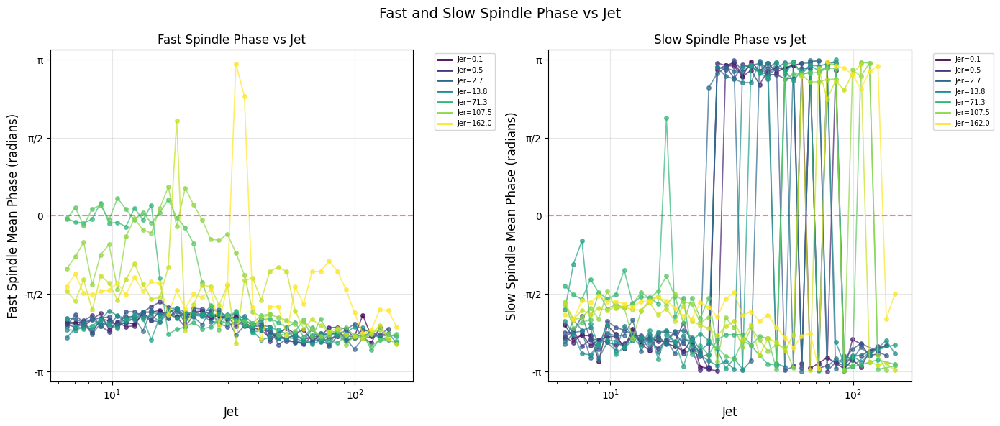

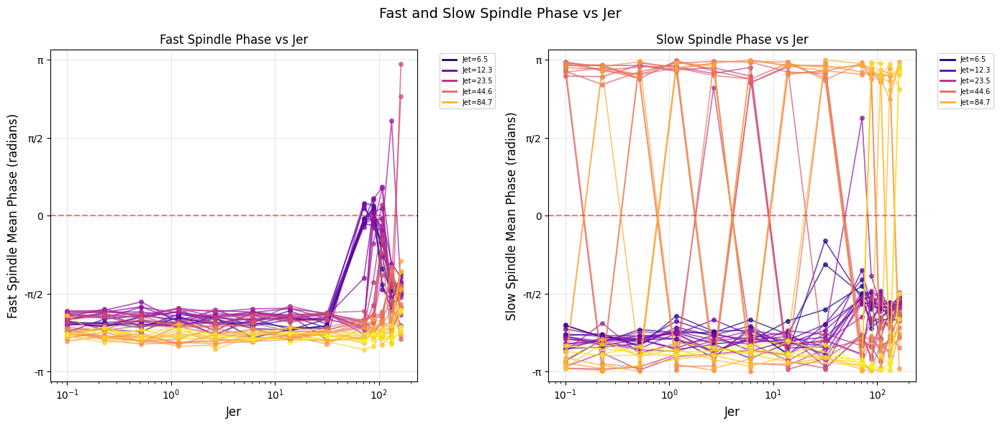

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd, pearsonr

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_expand_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phases, low=-np.pi, high=np.pi)
    std_phase = circstd(phases, low=-np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 获取所有 Jet 和 Jer 值 ==========
Jet_values_all = sorted(df['Jet'].unique())
Jer_values_all = sorted(df['Jer'].unique())

# 去掉你不想显示的值（修改这里即可）
Jet_values_all = Jet_values_all#[:-1]  # 去掉最后一个（最大值）
Jer_values_all = Jer_values_all#[:-1]  # 去掉最后一个（最大值）

print(f"\n使用的 Jet 值: {Jet_values_all}")
print(f"使用的 Jer 值: {Jer_values_all}")

# ========== 计算每个 (Jet, Jer) 组合下快慢纺锤波的相位 ==========
fast_phase = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_phase')

slow_phase = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circmean(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_phase')

fast_std = df[df['type'] == 'fast'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='fast_std')

slow_std = df[df['type'] == 'slow'].groupby(['Jet', 'Jer'])['phase_at_peak'].apply(
    lambda x: circstd(x.dropna(), low=-np.pi, high=np.pi) if len(x.dropna()) > 5 else np.nan
).reset_index(name='slow_std')

# 合并
phase_df = pd.merge(fast_phase, slow_phase, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, fast_std, on=['Jet', 'Jer'])
phase_df = pd.merge(phase_df, slow_std, on=['Jet', 'Jer'])
phase_df['phase_diff'] = phase_df['fast_phase'] - phase_df['slow_phase']
phase_df = phase_df.dropna()

# ========== 关键：用 Jet_values_all 和 Jer_values_all 过滤 phase_df ==========
phase_df_filtered = phase_df[
    (phase_df['Jet'].isin(Jet_values_all)) & 
    (phase_df['Jer'].isin(Jer_values_all))
].copy()

print(f"\n原始有效参数组合数: {len(phase_df)}")
print(f"过滤后有效参数组合数: {len(phase_df_filtered)}")

# ========== 图2：快慢纺锤波各自的相位 vs Jet ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = plt.cm.viridis(np.linspace(0, 1, len(Jer_values_all)))

# 左图：快纺锤波相位 vs Jet
ax = axes[0]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['fast_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=colors[i], lw=2, label=f'Jer={Jer_values_all[i]:.1f}') 
                   for i in range(0, len(Jer_values_all), max(1, len(Jer_values_all)//5))]
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jet
ax = axes[1]
for i, Jer_val in enumerate(Jer_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jer'] - Jer_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jet')
        ax.plot(subset_sorted['Jet'], subset_sorted['slow_phase'], 
                'o-', color=colors[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jet', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jet', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢纺锤波各自的相位 vs Jer ==========
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors2 = plt.cm.plasma(np.linspace(0, 1, len(Jet_values_all)))

# 左图：快纺锤波相位 vs Jer
ax = axes[0]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['fast_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Fast Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Fast Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)

legend_elements2 = [Line2D([0], [0], color=colors2[i], lw=2, label=f'Jet={Jet_values_all[i]:.1f}') 
                    for i in range(0, len(Jet_values_all), max(1, len(Jet_values_all)//5))]
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 右图：慢纺锤波相位 vs Jer
ax = axes[1]
for i, Jet_val in enumerate(Jet_values_all):
    subset = phase_df_filtered[np.abs(phase_df_filtered['Jet'] - Jet_val) < 1e-6]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jer')
        ax.plot(subset_sorted['Jer'], subset_sorted['slow_phase'], 
                'o-', color=colors2[i], alpha=0.7, linewidth=1.2, markersize=4)
ax.set_xlabel('Jer', fontsize=12)
ax.set_ylabel('Slow Spindle Mean Phase (radians)', fontsize=12)
ax.set_title('Slow Spindle Phase vs Jer', fontsize=12)
ax.set_xscale('log')
ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.legend(handles=legend_elements2, fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.suptitle('Fast and Slow Spindle Phase vs Jer', fontsize=14)
plt.tight_layout()
plt.show()

### 以下的csv名称未改

总纺锤波数: 52603
Jet 范围: 6.50 ~ 148.50
Jer 范围: 0.10 ~ 162.00

目标 Jer: 162, 实际最近值: 162.0000


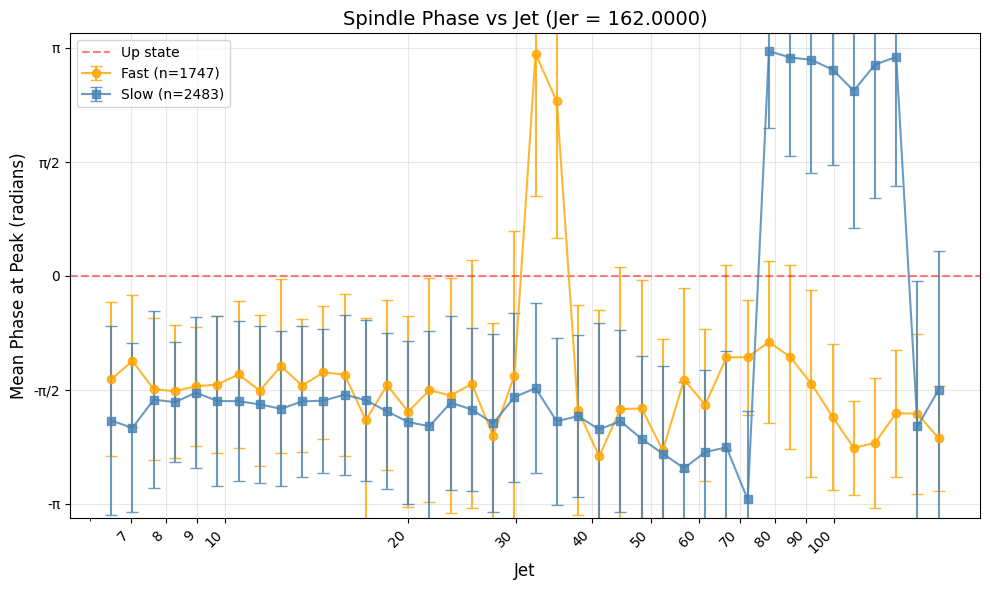


统计摘要 (Jer = 162.0000)
Jet=6.5000: Fast mean=-1.427±1.065 rad (n=58) Slow mean=-1.997±1.298 rad (n=60)
Jet=7.0430: Fast mean=-1.175±0.916 rad (n=51) Slow mean=-2.095±1.162 rad (n=58)
Jet=7.6313: Fast mean=-1.563±0.974 rad (n=62) Slow mean=-1.708±1.225 rad (n=60)
Jet=8.2687: Fast mean=-1.591±0.915 rad (n=46) Slow mean=-1.742±0.830 rad (n=55)
Jet=8.9594: Fast mean=-1.523±0.819 rad (n=47) Slow mean=-1.610±1.040 rad (n=49)
Jet=9.7078: Fast mean=-1.500±0.948 rad (n=52) Slow mean=-1.727±1.178 rad (n=58)
Jet=10.5187: Fast mean=-1.360±1.018 rad (n=38) Slow mean=-1.729±1.101 rad (n=64)
Jet=11.3973: Fast mean=-1.584±1.037 rad (n=57) Slow mean=-1.773±1.078 rad (n=60)
Jet=12.3494: Fast mean=-1.247±1.197 rad (n=50) Slow mean=-1.834±1.067 rad (n=61)
Jet=13.3809: Fast mean=-1.513±0.921 rad (n=50) Slow mean=-1.732±1.036 rad (n=61)
Jet=14.4986: Fast mean=-1.331±0.919 rad (n=51) Slow mean=-1.722±0.991 rad (n=58)
Jet=15.7097: Fast mean=-1.363±1.118 rad (n=47) Slow mean=-1.639±1.104 rad (n=63)
Jet=17.0220

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd, pearsonr

# ========== 读取数据 ==========

df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_expand_explore.csv")


# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 圆形统计函数 ==========
def circular_stats(phases):
    if len(phases) == 0:
        return np.nan, np.nan
    mean_phase = circmean(phases, low=-np.pi, high=np.pi)
    std_phase = circstd(phases, low=-np.pi, high=np.pi)
    return mean_phase, std_phase

# ========== 获取所有 Jet 值 ==========
Jet_values = sorted(df['Jet'].unique())

# ========== 找到最接近 71.3 的 Jer 值 ==========
target_Jer = 162
all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 计算该 Jer 下每个 Jet 的快慢纺锤波相位 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]

fast_means = []
fast_stds = []
slow_means = []
slow_stds = []
fast_ns = []
slow_ns = []
jet_vals = []

for jet_val in sorted(jer_filtered['Jet'].unique()):
    subset = jer_filtered[jer_filtered['Jet'] == jet_val]
    
    # 快纺锤波
    fast_phases = subset[subset['type'] == 'fast']['phase_at_peak'].dropna().values
    if len(fast_phases) > 0:
        m, s = circular_stats(fast_phases)
        fast_means.append(m)
        fast_stds.append(s)
        fast_ns.append(len(fast_phases))
    else:
        fast_means.append(np.nan)
        fast_stds.append(np.nan)
        fast_ns.append(0)
    
    # 慢纺锤波
    slow_phases = subset[subset['type'] == 'slow']['phase_at_peak'].dropna().values
    if len(slow_phases) > 0:
        m, s = circular_stats(slow_phases)
        slow_means.append(m)
        slow_stds.append(s)
        slow_ns.append(len(slow_phases))
    else:
        slow_means.append(np.nan)
        slow_stds.append(np.nan)
        slow_ns.append(0)
    
    jet_vals.append(jet_val)

jet_vals = np.array(jet_vals)
fast_means = np.array(fast_means)
fast_stds = np.array(fast_stds)
slow_means = np.array(slow_means)
slow_stds = np.array(slow_stds)

valid_fast = ~np.isnan(fast_means)
valid_slow = ~np.isnan(slow_means)

# ========== 画图 ==========
fig, ax = plt.subplots(figsize=(10, 6))

# 快纺锤波（带误差棒）
if np.any(valid_fast):
    ax.errorbar(jet_vals[valid_fast], fast_means[valid_fast], 
                yerr=fast_stds[valid_fast],
                fmt='o-', color='orange', capsize=4, 
                label=f'Fast (n={sum(fast_ns)})', 
                markersize=6, linewidth=1.5, alpha=0.8)

# 慢纺锤波（带误差棒）
if np.any(valid_slow):
    ax.errorbar(jet_vals[valid_slow], slow_means[valid_slow], 
                yerr=slow_stds[valid_slow],
                fmt='s-', color='steelblue', capsize=4, 
                label=f'Slow (n={sum(slow_ns)})', 
                markersize=6, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Mean Phase at Peak (radians)', fontsize=12)
ax.set_title(f'Spindle Phase vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xscale('log')

# ========== 设置更细致的横坐标刻度 ==========
# 生成从 1 到 200 的刻度值（对数坐标下均匀分布）
xticks_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200]
# 只保留在 Jet 范围内的刻度
xticks_values = [v for v in xticks_values if v >= min(jet_vals) and v <= max(jet_vals)]
# 如果最小 Jet 小于 1，添加 0.1 和 0.5
if min(jet_vals) < 1:
    xticks_values = [0.1, 0.5] + xticks_values
ax.set_xticks(xticks_values)
ax.set_xticklabels([str(v) for v in xticks_values], rotation=45, ha='right')

ax.set_ylim(-np.pi - 0.2, np.pi + 0.2)
ax.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_yticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Up state')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jer = {closest_Jer:.4f})")
print("="*60)

for jet, fm, fs, sm, ss, fn, sn in zip(jet_vals, fast_means, fast_stds, slow_means, slow_stds, fast_ns, slow_ns):
    if not np.isnan(fm) or not np.isnan(sm):
        line = f"Jet={jet:.4f}:"
        if not np.isnan(fm):
            line += f" Fast mean={fm:.3f}±{fs:.3f} rad (n={fn})"
        if not np.isnan(sm):
            line += f" Slow mean={sm:.3f}±{ss:.3f} rad (n={sn})"
        print(line)

总纺锤波数: 52603
Jet 范围: 6.50 ~ 148.50
Jer 范围: 0.10 ~ 162.00

目标 Jer: 162, 实际最近值: 162.0000


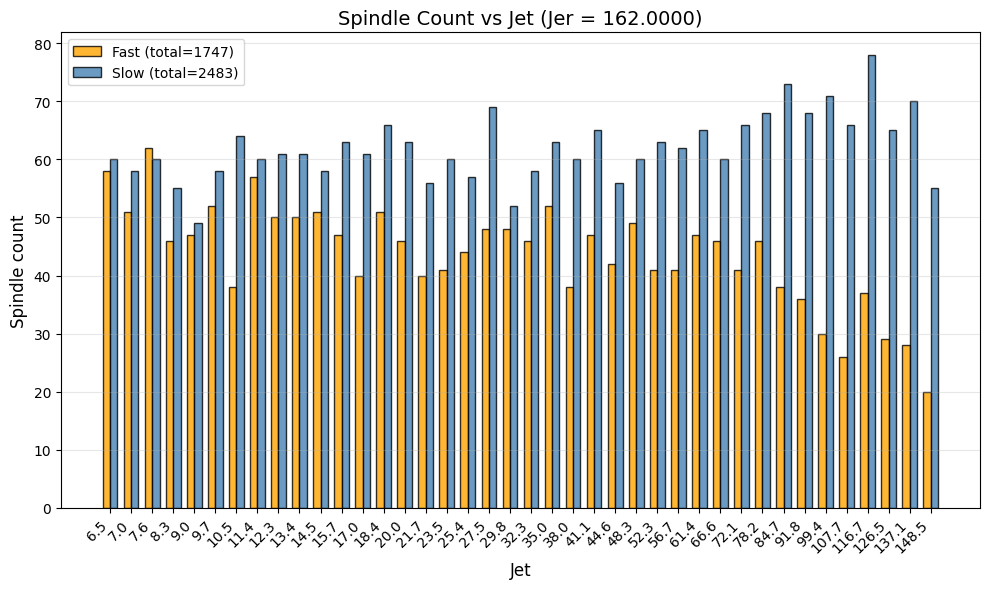


统计摘要 (Jer = 162.0000)
       Jet     Fast     Slow    Total
--------------------------------------
       6.5       58       60      118
       7.0       51       58      109
       7.6       62       60      122
       8.3       46       55      101
       9.0       47       49       96
       9.7       52       58      110
      10.5       38       64      102
      11.4       57       60      117
      12.3       50       61      111
      13.4       50       61      111
      14.5       51       58      109
      15.7       47       63      110
      17.0       40       61      101
      18.4       51       66      117
      20.0       46       63      109
      21.7       40       56       96
      23.5       41       60      101
      25.4       44       57      101
      27.5       48       69      117
      29.8       48       52      100
      32.3       46       58      104
      35.0       52       63      115
      38.0       38       60       98
      41.1       47       

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_expand_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 找到最接近 71.3 的 Jer 值 ==========

all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 筛选该 Jer 下的数据 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]

# ========== 统计每个 Jet 下的快慢纺锤波个数 ==========
jet_vals = []
fast_counts = []
slow_counts = []

for jet_val in sorted(jer_filtered['Jet'].unique()):
    subset = jer_filtered[jer_filtered['Jet'] == jet_val]
    
    fast_count = len(subset[subset['type'] == 'fast'])
    slow_count = len(subset[subset['type'] == 'slow'])
    
    jet_vals.append(jet_val)
    fast_counts.append(fast_count)
    slow_counts.append(slow_count)

jet_vals = np.array(jet_vals)
fast_counts = np.array(fast_counts)
slow_counts = np.array(slow_counts)

# ========== 画图：快慢纺锤波个数随 Jet 变化 ==========
fig, ax = plt.subplots(figsize=(10, 6))

width = 0.35
x = np.arange(len(jet_vals))

ax.bar(x - width/2, fast_counts, width, color='orange', edgecolor='black', 
       label=f'Fast (total={sum(fast_counts)})', alpha=0.8)
ax.bar(x + width/2, slow_counts, width, color='steelblue', edgecolor='black', 
       label=f'Slow (total={sum(slow_counts)})', alpha=0.8)

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Spindle count', fontsize=12)
ax.set_title(f'Spindle Count vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'{v:.1f}' for v in jet_vals], rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jer = {closest_Jer:.4f})")
print("="*60)
print(f"{'Jet':>10} {'Fast':>8} {'Slow':>8} {'Total':>8}")
print("-"*38)
for j, fc, sc in zip(jet_vals, fast_counts, slow_counts):
    print(f"{j:>10.1f} {fc:>8} {sc:>8} {fc+sc:>8}")
print("-"*38)
print(f"{'Total':>10} {sum(fast_counts):>8} {sum(slow_counts):>8} {sum(fast_counts)+sum(slow_counts):>8}")

#### 原本那个输出B结果的代码找不到了

总纺锤波数: 52603

目标 Jer: 162, 实际最近值: 162.0000


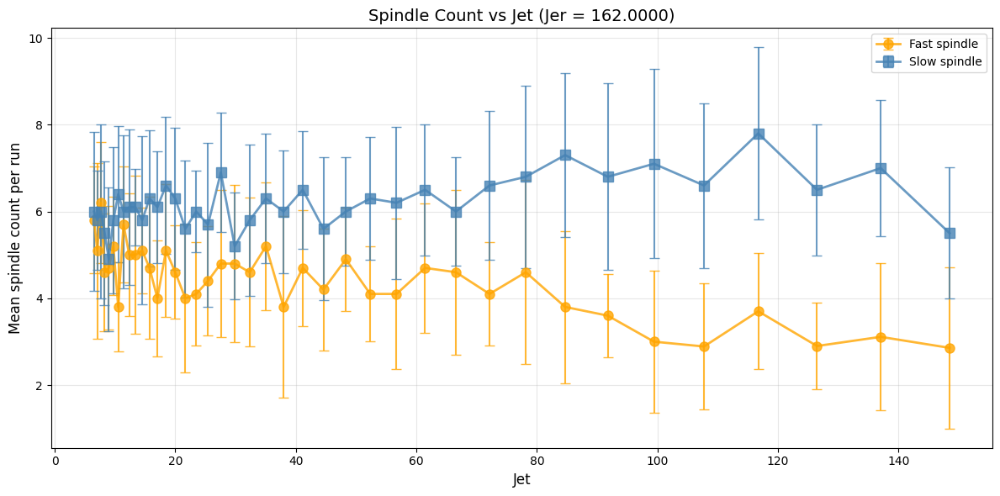


统计摘要 (Jer = 162.0000)
       Jet    Fast mean   Fast std    Slow mean   Slow std
--------------------------------------------------------
       6.5         5.80       1.23         6.00       1.83
       7.0         5.10       2.02         5.80       1.14
       7.6         6.20       1.40         6.00       2.00
       8.3         4.60       1.35         5.50       1.65
       9.0         4.70       1.42         4.90       1.66
       9.7         5.20       1.14         5.80       1.69
      10.5         3.80       1.03         6.40       1.58
      11.4         5.70       1.34         6.00       1.76
      12.3         5.00       1.41         6.10       1.79
      13.4         5.00       1.83         6.10       0.88
      14.5         5.10       0.99         5.80       1.93
      15.7         4.70       1.64         6.30       1.57
      17.0         4.00       1.33         6.10       1.29
      18.4         5.10       1.52         6.60       1.58
      20.0         4.60       1.07 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_expand_explore.csv")

if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")

# ========== 找到最接近 71.3 的 Jer 值 ==========
target_Jer = 162
all_Jer_values = sorted(df['Jer'].unique())
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))
print(f"\n目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 筛选该 Jer 下的数据 ==========
jer_filtered = df[np.abs(df['Jer'] - closest_Jer) < 1e-6]

# ========== 按 Jet, seed, type 分组计数 ==========
seed_counts = jer_filtered.groupby(['Jet', 'seed', 'type']).size().reset_index(name='count')

# ========== 按 Jet, type 分组，计算均值和标准差 ==========
stats = seed_counts.groupby(['Jet', 'type']).agg(
    mean_count=('count', 'mean'),
    std_count=('count', 'std')
).reset_index()

# ========== 分离快慢 ==========
fast_stats = stats[stats['type'] == 'fast'][['Jet', 'mean_count', 'std_count']].rename(
    columns={'mean_count': 'fast_mean', 'std_count': 'fast_std'})
slow_stats = stats[stats['type'] == 'slow'][['Jet', 'mean_count', 'std_count']].rename(
    columns={'mean_count': 'slow_mean', 'std_count': 'slow_std'})

plot_df = pd.merge(fast_stats, slow_stats, on='Jet', how='outer').fillna(0)
plot_df = plot_df.sort_values('Jet')

# ========== 画折线图（带误差棒） ==========
fig, ax = plt.subplots(figsize=(12, 6))

# 快纺锤波
ax.errorbar(plot_df['Jet'], plot_df['fast_mean'], yerr=plot_df['fast_std'],
            fmt='o-', color='orange', capsize=4, markersize=8, linewidth=2,
            label='Fast spindle', alpha=0.8, elinewidth=1.5)

# 慢纺锤波
ax.errorbar(plot_df['Jet'], plot_df['slow_mean'], yerr=plot_df['slow_std'],
            fmt='s-', color='steelblue', capsize=4, markersize=8, linewidth=2,
            label='Slow spindle', alpha=0.8, elinewidth=1.5)

ax.set_xlabel('Jet', fontsize=12)
ax.set_ylabel('Mean spindle count per run', fontsize=12)
ax.set_title(f'Spindle Count vs Jet (Jer = {closest_Jer:.4f})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='both')

plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print(f"统计摘要 (Jer = {closest_Jer:.4f})")
print("="*60)
print(f"{'Jet':>10} {'Fast mean':>12} {'Fast std':>10} {'Slow mean':>12} {'Slow std':>10}")
print("-"*56)
for _, row in plot_df.iterrows():
    print(f"{row['Jet']:>10.1f} {row['fast_mean']:>12.2f} {row['fast_std']:>10.2f} "
          f"{row['slow_mean']:>12.2f} {row['slow_std']:>10.2f}")

总纺锤波数: 52603
Jet 范围: 6.50 ~ 148.50
Jer 范围: 0.10 ~ 162.00

目标 Jet: 80, 实际最近值: 78.1620
目标 Jer: 162, 实际最近值: 162.0000

筛选后的纺锤波总数: 114
快纺锤波: 46
慢纺锤波: 68
包含的 seed: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

快纺锤波 phase_at_peak 数量: 46
慢纺锤波 phase_at_peak 数量: 68


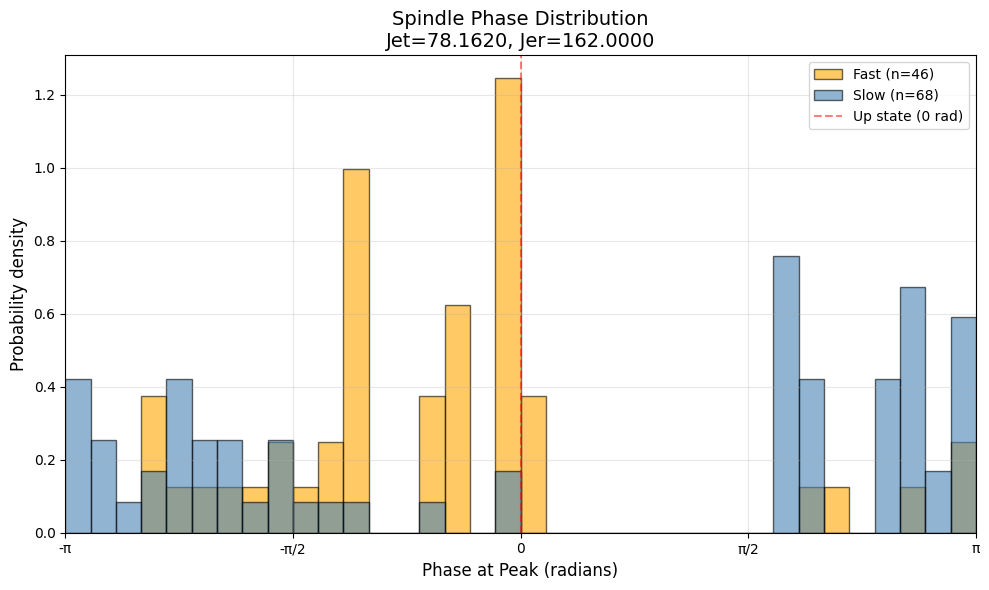

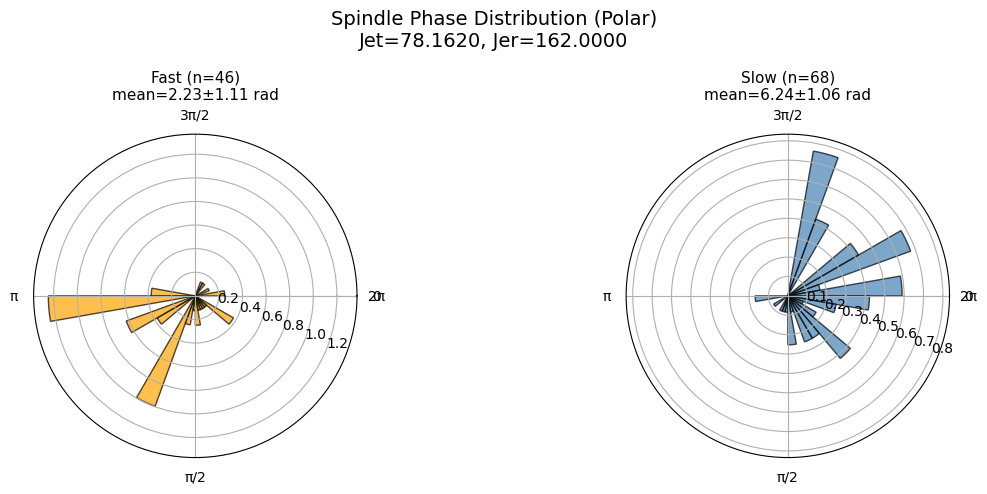

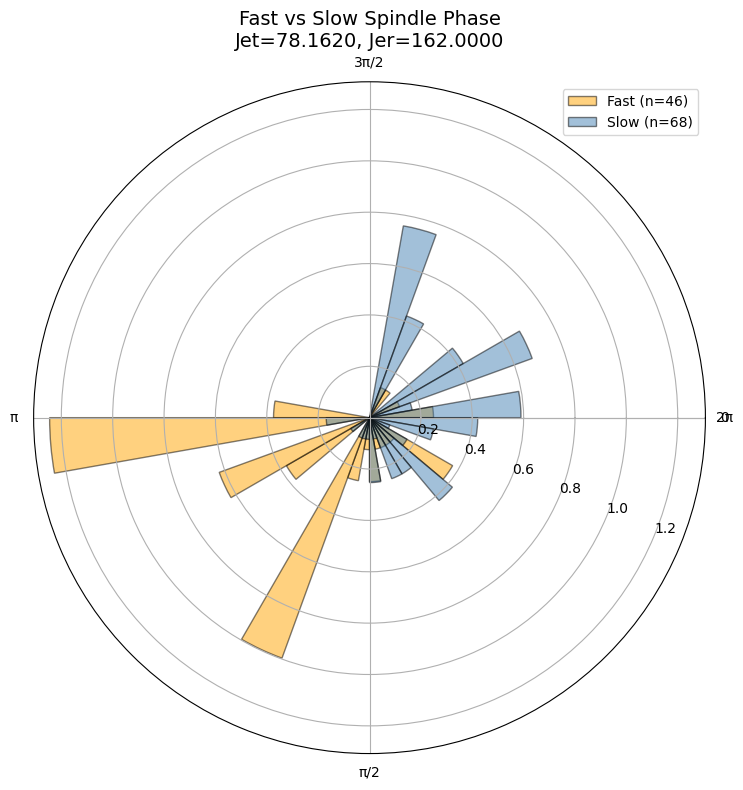


统计摘要
Fast: n=46, mean=-0.913 rad, std=1.112 rad
Slow: n=68, mean=3.097 rad, std=1.064 rad


In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

# ========== 读取数据 ==========
df = pd.read_csv("data/analysis_data/spindles_Jet_Jer_scale0x0005_Jrta_expand_explore.csv")

# ========== 数据筛选 ==========
if 'masked' in df.columns:
    df = df[~df['masked']].copy()

print(f"总纺锤波数: {len(df)}")
print(f"Jet 范围: {df['Jet'].min():.2f} ~ {df['Jet'].max():.2f}")
print(f"Jer 范围: {df['Jer'].min():.2f} ~ {df['Jer'].max():.2f}")

# ========== 找到最接近的目标值 ==========
target_Jet = 80
target_Jer = 162

all_Jet_values = sorted(df['Jet'].unique())
all_Jer_values = sorted(df['Jer'].unique())

closest_Jet = min(all_Jet_values, key=lambda x: abs(x - target_Jet))
closest_Jer = min(all_Jer_values, key=lambda x: abs(x - target_Jer))

print(f"\n目标 Jet: {target_Jet}, 实际最近值: {closest_Jet:.4f}")
print(f"目标 Jer: {target_Jer}, 实际最近值: {closest_Jer:.4f}")

# ========== 筛选目标参数 ==========
df_filtered = df[(np.abs(df['Jet'] - closest_Jet) < 1e-6) & 
                 (np.abs(df['Jer'] - closest_Jer) < 1e-6)]

print(f"\n筛选后的纺锤波总数: {len(df_filtered)}")
print(f"快纺锤波: {len(df_filtered[df_filtered['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_filtered[df_filtered['type'] == 'slow'])}")

# 显示有哪些 seed
seeds = sorted(df_filtered['seed'].unique())
print(f"包含的 seed: {seeds}")

# ========== 提取 phase_at_peak ==========
fast_phases = df_filtered[df_filtered['type'] == 'fast']['phase_at_peak'].dropna().values
slow_phases = df_filtered[df_filtered['type'] == 'slow']['phase_at_peak'].dropna().values

print(f"\n快纺锤波 phase_at_peak 数量: {len(fast_phases)}")
print(f"慢纺锤波 phase_at_peak 数量: {len(slow_phases)}")

# ========== 将相位从 -π~π 转换到 0~2π ==========
def phase_to_0_2pi(phases):
    return (phases + np.pi) % (2 * np.pi)

fast_phases_0_2pi = phase_to_0_2pi(fast_phases) if len(fast_phases) > 0 else np.array([])
slow_phases_0_2pi = phase_to_0_2pi(slow_phases) if len(slow_phases) > 0 else np.array([])

# ========== 图1：线性直方图（叠加对比）==========
fig, ax = plt.subplots(figsize=(10, 6))

if len(fast_phases) > 0:
    ax.hist(fast_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='orange', edgecolor='black', density=True, 
            label=f'Fast (n={len(fast_phases)})')
if len(slow_phases) > 0:
    ax.hist(slow_phases, bins=36, range=(-np.pi, np.pi), alpha=0.6,
            color='steelblue', edgecolor='black', density=True, 
            label=f'Slow (n={len(slow_phases)})')

ax.set_xlabel('Phase at Peak (radians)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Spindle Phase Distribution\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
ax.set_xlim(-np.pi, np.pi)
ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
ax.set_xticklabels(['-π', '-π/2', '0', 'π/2', 'π'])
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Up state (0 rad)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 图2：极坐标直方图（左右并排）==========
fig, axes = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'polar'})

n_bins = 36
bins = np.linspace(0, 2*np.pi, n_bins + 1)
bin_centers = (bins[:-1] + bins[1:]) / 2
width = 2 * np.pi / n_bins

for idx, (phases, label, color) in enumerate([
    (fast_phases_0_2pi, f'Fast (n={len(fast_phases)})', 'orange'),
    (slow_phases_0_2pi, f'Slow (n={len(slow_phases)})', 'steelblue')
]):
    ax = axes[idx]
    if len(phases) > 0:
        hist, _ = np.histogram(phases, bins=bins, density=True)
        ax.bar(bin_centers, hist, width=width, color=color, edgecolor='black', alpha=0.7)
        mean_p = circmean(phases, low=0, high=2*np.pi)
        std_p = circstd(phases, low=0, high=2*np.pi)
        ax.set_title(f'{label}\nmean={mean_p:.2f}±{std_p:.2f} rad', fontsize=11)
        ax.set_ylim(0, max(hist) * 1.1 if len(hist) > 0 else 0.6)
    else:
        ax.text(0, 0, 'No data', ha='center', va='center')
        ax.set_title(label, fontsize=11)
        ax.set_ylim(0, 0.6)
    
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(-1)
    ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
    ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

plt.suptitle(f'Spindle Phase Distribution (Polar)\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

# ========== 图3：快慢叠加在同一极坐标图上 ==========
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

if len(fast_phases_0_2pi) > 0:
    hist_fast, _ = np.histogram(fast_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_fast, width=width, color='orange', edgecolor='black', 
           alpha=0.5, label=f'Fast (n={len(fast_phases)})')
if len(slow_phases_0_2pi) > 0:
    hist_slow, _ = np.histogram(slow_phases_0_2pi, bins=bins, density=True)
    ax.bar(bin_centers, hist_slow, width=width, color='steelblue', edgecolor='black', 
           alpha=0.5, label=f'Slow (n={len(slow_phases)})')

ax.set_title(f'Fast vs Slow Spindle Phase\nJet={closest_Jet:.4f}, Jer={closest_Jer:.4f}', fontsize=14)
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# ========== 打印统计信息 ==========
print("\n" + "="*60)
print("统计摘要")
print("="*60)

for name, phases in [('Fast', fast_phases), ('Slow', slow_phases)]:
    if len(phases) > 0:
        mean_p = circmean(phases, low=-np.pi, high=np.pi)
        std_p = circstd(phases, low=-np.pi, high=np.pi)
        print(f"{name}: n={len(phases)}, mean={mean_p:.3f} rad, std={std_p:.3f} rad")
    else:
        print(f"{name}: 无数据")